<a href="https://colab.research.google.com/github/bhausaheb-pachaptil/Basics-of-Python-/blob/main/BSP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip install neurokit2

In [27]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

record = wfdb.rdrecord('101', pn_dir='mitdb')
ecg = record.p_signal[:,0]
fs = record.fs

print("Sampling Frequency:", fs)
print("Total Samples:", len(ecg))

Sampling Frequency: 360
Total Samples: 650000


In [28]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

record = wfdb.rdrecord('100', pn_dir='mitdb')
ecg = record.p_signal[:,0]
fs = record.fs

print("Sampling Frequency:", fs)
print("Total Samples:", len(ecg))

Sampling Frequency: 360
Total Samples: 650000


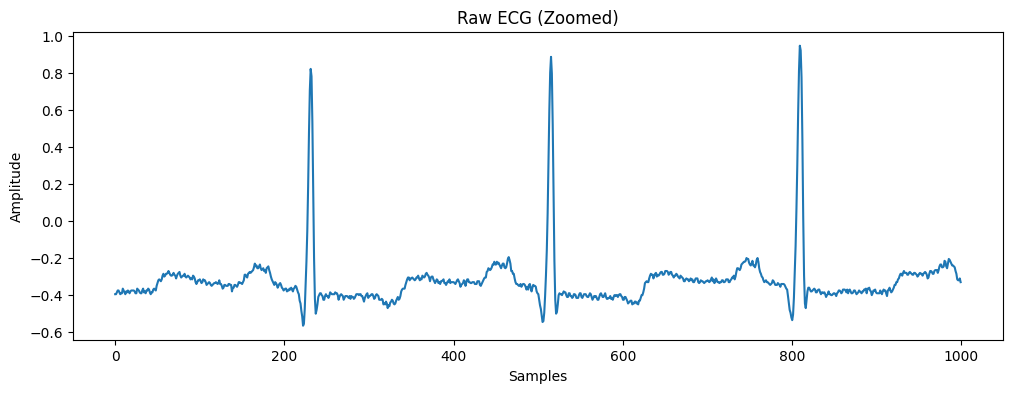

In [29]:
plt.figure(figsize=(12,4))
plt.plot(ecg[1000:2000])
plt.title("Raw ECG (Zoomed)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

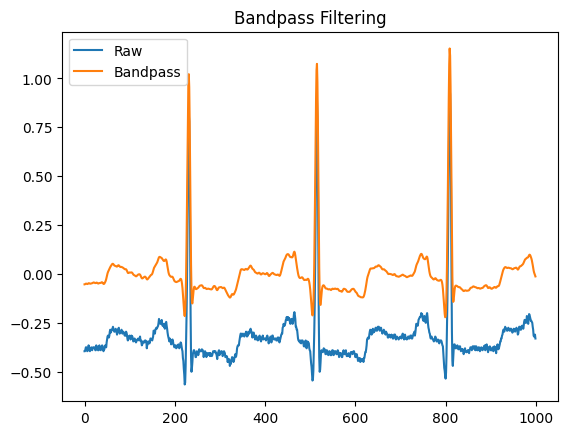

In [30]:
import neurokit2 as nk

ecg_bandpass = nk.signal_filter(ecg, sampling_rate=fs, lowcut=0.5, highcut=40)

plt.plot(ecg[1000:2000], label="Raw")
plt.plot(ecg_bandpass[1000:2000], label="Bandpass")
plt.legend()
plt.title("Bandpass Filtering")
plt.show()

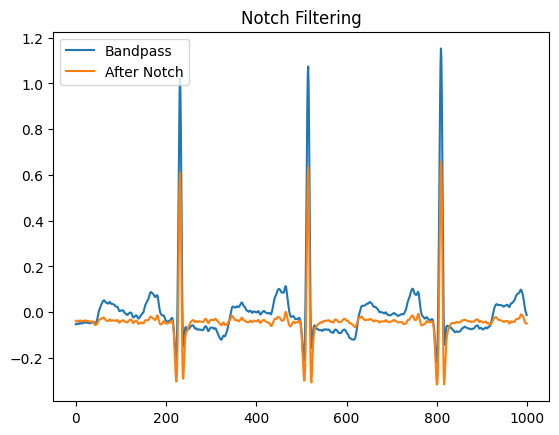

In [31]:
ecg_notch = nk.signal_filter(ecg_bandpass, sampling_rate=fs, method='iirnotch', powerline=50) # Corrected method to 'iirnotch' for notch filtering

plt.plot(ecg_bandpass[1000:2000], label="Bandpass")
plt.plot(ecg_notch[1000:2000], label="After Notch")
plt.legend()
plt.title("Notch Filtering")
plt.show()

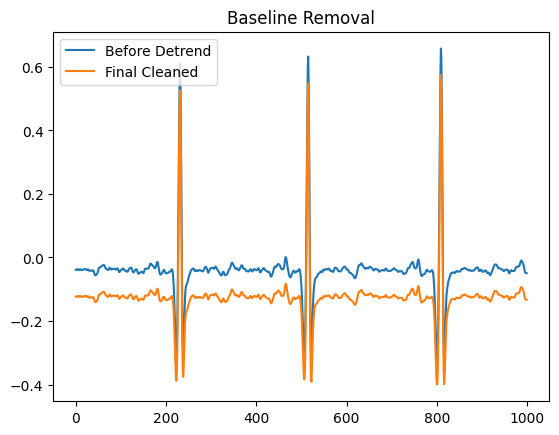

In [32]:
ecg_cleaned = nk.signal_detrend(ecg_notch)

plt.plot(ecg_notch[1000:2000], label="Before Detrend")
plt.plot(ecg_cleaned[1000:2000], label="Final Cleaned")
plt.legend()
plt.title("Baseline Removal")
plt.show()

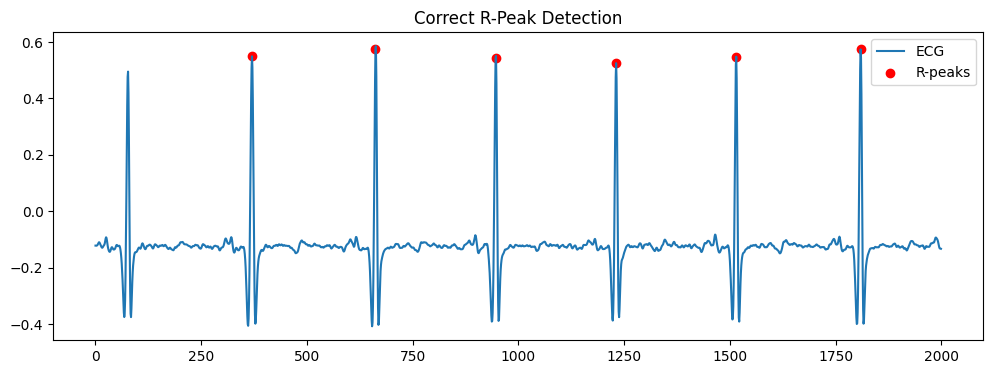

In [33]:
signals, info = nk.ecg_process(ecg_cleaned, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]

# Plot correctly
plt.figure(figsize=(12,4))
plt.plot(ecg_cleaned[:2000], label="ECG")

# Plot only actual peak positions
plt.scatter(r_peaks[r_peaks < 2000],
            ecg_cleaned[r_peaks[r_peaks < 2000]],
            color='red', label='R-peaks')

plt.legend()
plt.title("Correct R-Peak Detection")
plt.show()

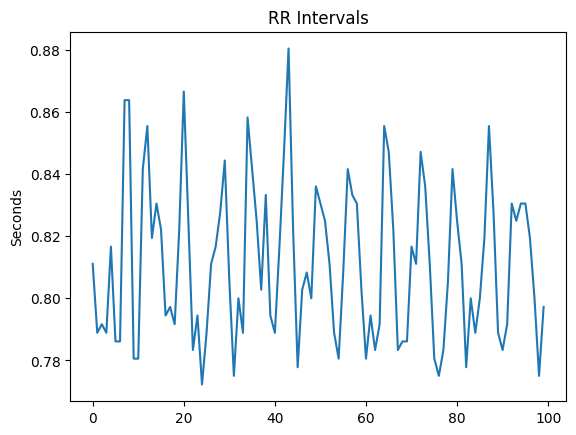

In [34]:
rr_intervals = np.diff(r_peaks) / fs

plt.plot(rr_intervals[:100])
plt.title("RR Intervals")
plt.ylabel("Seconds")
plt.show()

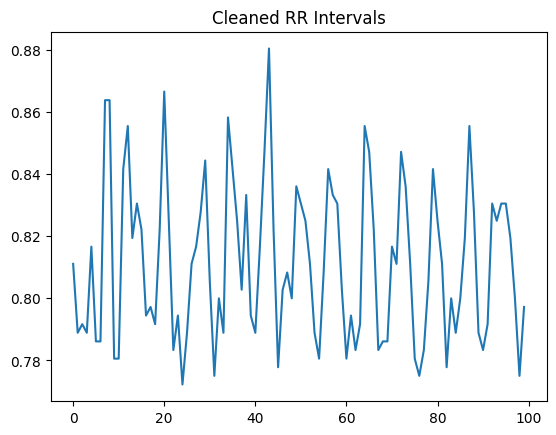

In [35]:
rr_intervals = rr_intervals[(rr_intervals > 0.3) & (rr_intervals < 1.5)]

plt.plot(rr_intervals[:100])
plt.title("Cleaned RR Intervals")
plt.show()

In [36]:
mean_rr = np.mean(rr_intervals)
sdnn = np.std(rr_intervals)
rmssd = np.sqrt(np.mean(np.square(np.diff(rr_intervals))))

print("Mean RR:", mean_rr)
print("SDNN:", sdnn)
print("RMSSD:", rmssd)

Mean RR: 0.794619432207538
SDNN: 0.03779652400973943
RMSSD: 0.032310033942554536


In [37]:
if rmssd < 0.03:
    print("High Stress")
elif rmssd < 0.06:
    print("Moderate Stress")
else:
    print("Relaxed")

Moderate Stress


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_Symbolic_EqualProb4_0V,HRV_Symbolic_EqualProb4_1V,HRV_Symbolic_EqualProb4_2LV,HRV_Symbolic_EqualProb4_2UV
0,794.619432,37.804852,19.657675,31.522808,18.276949,32.586619,16.126781,34.141332,32.310034,32.317113,...,1.374057,2.178554,1.775581,1.963494,4.064108,0.766151,0.214286,0.503086,0.132275,0.150353


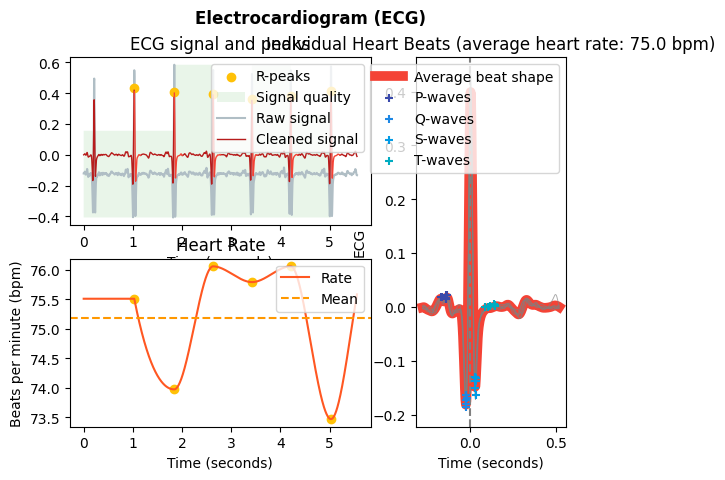

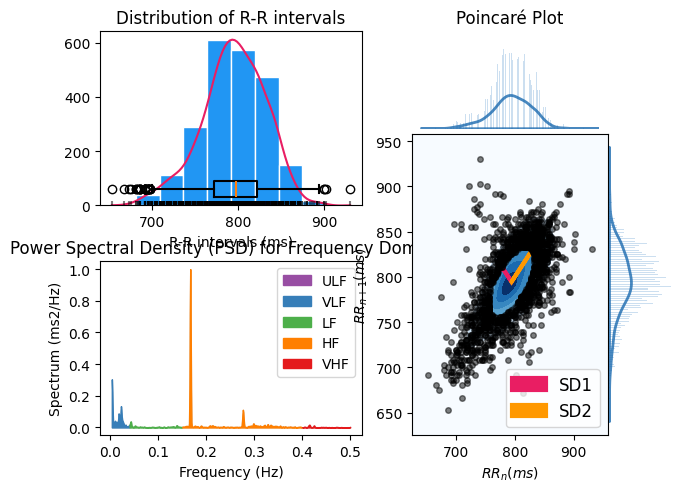

In [38]:
nk.ecg_plot(signals[:2000], info=info)
nk.hrv(r_peaks, sampling_rate=fs, show=True)